### Test Shotgun

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4"

from transformers import AutoModelForCausalLM, AutoTokenizer

from fastchat.utils import str_to_torch_dtype
from fastchat.model import get_conversation_template

from evaluation.inference_shotgun import shotgun_forward

from model.shotgun.lru_cache import ShotgunCache, ShotgunCacheConfig

In [2]:
bench_name = 'spec_bench'
model_path = '/home/zhiyao/work/Spec-Bench-Models/vicuna-7b-v1.3'
max_new_tokens = 1024
dtype = 'float16'

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=str_to_torch_dtype(dtype),
    low_cpu_mem_usage=True,
    device_map="auto"
)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(model_path)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [3]:
conv = get_conversation_template("vicuna")
conv.append_message(conv.roles[0], "Can you tell me a short joke?")
conv.append_message(conv.roles[1], None)
conv.stop_str = "</s>"
prompt = conv.get_prompt()
inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
shotgun_cache = ShotgunCache([
    ShotgunCacheConfig(
        prefix_capacity=2**20,
        followup_capacity=8,
        prefix_len=2,
        followup_len=2,
    )
])
output_ids, new_token, step, accept_length_tree = shotgun_forward(
    inputs,
    model,
    tokenizer,
    max_new_tokens,
    shotgun_cache,
)
output_ids, new_token, step, accept_length_tree = shotgun_forward(
    inputs,
    model,
    tokenizer,
    max_new_tokens,
    shotgun_cache,
)

In [4]:
output_ids = output_ids[0][len(inputs.input_ids[0]):]
output = tokenizer.decode(
    output_ids,
    spaces_between_special_tokens=False,
)

In [5]:
print(output)

Sure! Here's a short joke for you:

Why was the math book sad?

Because it had too many problems.</s><s>


In [6]:
accept_length_tree

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2]

### Learn Database

In [ ]:
import itertools
import multiprocessing as mp
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from model.shotgun.lru_cache import _open_db, _count_kgrams, _SCHEMA_P1

model_path = '/home/zhiyao/work/Spec-Bench-Models/vicuna-7b-v1.3'
data_stream = load_dataset("openwebtext", split="train", streaming=True, trust_remote_code=True)
total_examples = data_stream.info.splits["train"].num_examples
k = 3
num_workers = 24
batch_size  = 512

def batch_iter(stream, batch_size):
    it = iter(stream)
    while True:
        batch = list(itertools.islice(it, batch_size))
        if not batch:
            break
        yield batch

def construct_task(bit, num_workers):
    tasks = []
    for wid in range(num_workers):
        try:
            batch = next(bit)
        except StopIteration:
            break
        tasks.append((wid, batch))
    return tasks

def process_batch(worker_id, batch):
    with _open_db(f"openwebtext_pass1_worker{worker_id}.sqlite", _SCHEMA_P1) as conn:
        tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=True, use_cache=False, model_max_length=65536, legacy=True)
        for example in batch:
            tokens = tokenizer(example["text"])["input_ids"]
            _count_kgrams(tokens, k, conn)
        return worker_id, len(batch)

with mp.Pool(processes=num_workers) as pool:
    with tqdm(total=total_examples) as pbar:
        bit = batch_iter(data_stream, batch_size)
        tasks = construct_task(bit, num_workers)
        while True:
            if not tasks:
                break

            results = [
                pool.apply_async(process_batch, args=(wid, batch))
                for wid, batch in tasks
            ]

            tasks = construct_task(bit, num_workers)

            for r in results:
                worker_id, count = r.get()
                pbar.update(count)

        pool.close()
        pool.join()

In [ ]:
from model.shotgun.cache_builder import merge_kgram_counts

model_path = '/home/zhiyao/work/Spec-Bench-Models/vicuna-7b-v1.3'
dataset = 'openwebtext'
num_workers = 10
num_prev_workers = 40
db_dir = 'openwebtext_key3'
key_len = 3
thread_batch = 512

merge_kgram_counts(db_dir, dataset, num_workers, num_prev_workers, key_len)

In [5]:
from model.shotgun.cache_builder import get_top_kgrams

In [6]:
from transformers import AutoTokenizer
model_path = '/home/zhiyao/work/Spec-Bench-Models/vicuna-7b-v1.3'
tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=True, use_cache=False, model_max_length=65536, legacy=True)

In [ ]:
top = get_top_kgrams(50, "openwebtext_key3/openwebtext_cnt_ngram_merged.sqlite", key_len)
for toks, _ in top:
    print(repr(tokenizer.decode(toks)))

In [ ]:
top = get_top_kgrams(50, "openwebtext_key3_saved/openwebtext_cnt_ngram_merged.sqlite", key_len)
for toks, _ in top:
    print(repr(tokenizer.decode(toks)))

In [1]:
from model.shotgun.cache_builder import build_followup_counts, get_top_kgrams

model_path = '/home/zhiyao/work/Spec-Bench-Models/vicuna-7b-v1.3'
dataset = 'openwebtext'
num_workers = 20
db_dir = 'openwebtext_key2_val2'
key_len = 2
val_len = 2
thread_batch = 2048

top_prefixes = set(
    prefix for prefix, _cnt in
    get_top_kgrams(10000000, "openwebtext_key2/openwebtext_cnt_ngram_merged.sqlite", key_len)
)

In [2]:
show = []
for i, prefix in enumerate(top_prefixes):
    show.append(prefix)
    if i > 10:
        break
show


[(16033, 6959),
 (411, 21560),
 (471, 22365),
 (18973, 1016),
 (28503, 5019),
 (7716, 15983),
 (5652, 871),
 (29416, 785),
 (903, 2774),
 (925, 6505),
 (19985, 14511),
 (29314, 508)]

In [ ]:
build_followup_counts(model_path, dataset, db_dir, num_workers, key_len, val_len, top_prefixes, thread_batch)

  0%|          | 0/8013769 [00:00<?, ?it/s]

In [3]:
import sqlite3

def get_row_count(db_path: str, table_name: str) -> int:
    """Get the number of rows in a SQLite table.
    
    Args:
        db_path: Path to the SQLite database file
        table_name: Name of the table to count rows from
        
    Returns:
        Number of rows in the table
    """
    with sqlite3.connect(db_path) as conn:
        cur = conn.cursor()
        cur.execute(f"SELECT COUNT(*) FROM {table_name}")
        return cur.fetchone()[0]


In [ ]:
# Test it on the ngram counts table
db_path = "openwebtext_key3/openwebtext_cnt_ngram_merged.sqlite"
print(f"Number of rows in kgram_counts: {get_row_count(db_path, 'kgram_counts')}")

In [4]:
get_row_count("openwebtext_key2_val2/openwebtext_cnt_followup_worker9.sqlite", "followup_counts")

0

In [1]:
import sqlite3

def get_counts(db_path: str, table_name: str) -> list[int]:
    """Get all counts from a SQLite table as a list.
    
    Args:
        db_path: Path to the SQLite database file
        table_name: Name of the table to get counts from
        
    Returns:
        List of count values
    """
    with sqlite3.connect(db_path) as conn:
        cur = conn.cursor()
        cur.execute(f"SELECT cnt FROM {table_name}")
        lst = [count for (count,) in cur.fetchall()]
        return lst

# Test the iterator
db_path = "openwebtext_key2/openwebtext_cnt_ngram_merged.sqlite" 
counts = get_counts(db_path, "kgram_counts")


In [2]:
counts.sort(reverse=True)

Processing counts: 100%|██████████| 64461/64461 [00:00<00:00, 155409.15it/s]


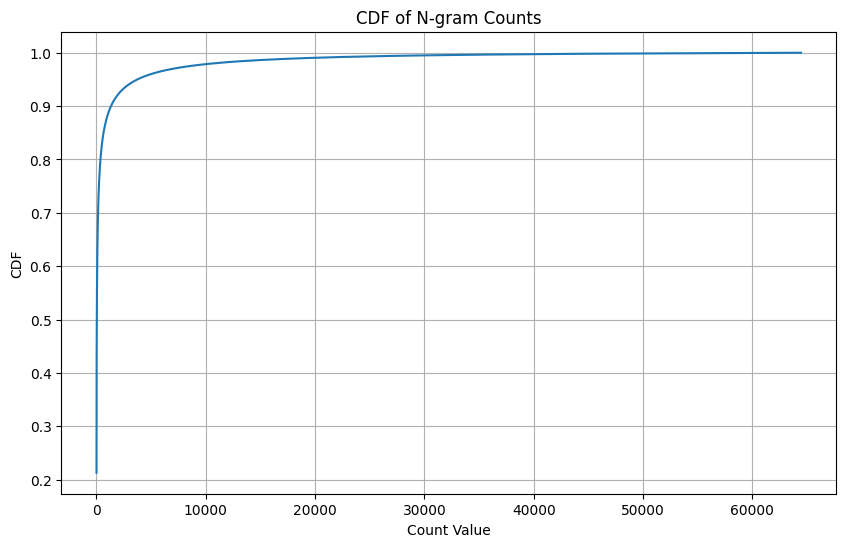

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

s = sum(counts)
running_s = 0
y = []
for i in tqdm(range(0, len(counts), 1000), desc="Processing counts"):
    batch = counts[i:i+1000]
    running_s += sum(batch)
    y.append(running_s / s)
x = np.arange(1, len(y) + 1)


# Create CDF plot
plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.grid(True)
plt.xlabel('Count Value')
plt.ylabel('CDF')
plt.title('CDF of N-gram Counts')
plt.show()


In [4]:
l = len(counts)
sum(counts[:int(l * 0.01)]) / s

0.8501686966045305

In [ ]:
from model.shotgun.cache_builder import build_lru_cache

top_prefix_n = 10000000
top_followup_n = 32
prefix_db_path = "openwebtext_sample100/prefix2_followup3/openwebtext_cnt_ngram_merged.sqlite"
followup_db_path = "openwebtext_key2_val2/openwebtext_cnt_followup_merged.sqlite"
prefix_len = 2
followup_len = 2
output_path = "openwebtext_lru_cache_key2_val2.pkl"

build_lru_cache(top_prefix_n, top_followup_n, prefix_db_path, followup_db_path, prefix_len, followup_len, output_path)


In [3]:
import transformers
print(transformers.__version__)


4.37.1


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# load tokenizer & model, telling HF to pull in the custom Mamba code
tokenizer = AutoTokenizer.from_pretrained("state-spaces/mamba-130m-hf")
model     = AutoModelForCausalLM.from_pretrained(
    "state-spaces/mamba-130m-hf",
    trust_remote_code=True       # <-- allow custom Mamba model code
)

# generate
prompt = "Once upon a time, "
input_ids = tokenizer(prompt, return_tensors="pt").input_ids
out = model.generate(input_ids, max_new_tokens=50)
print(tokenizer.decode(out[0], skip_special_tokens=True))

/home/zhiyao/anaconda3/envs/specbench/lib/python3.12/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


ValueError: The checkpoint you are trying to load has model type `mamba` but Transformers does not recognize this architecture. This could be because of an issue with the checkpoint, or because your version of Transformers is out of date.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4"
import time

import torch

from transformers import AutoModelForCausalLM, AutoTokenizer

from fastchat.utils import str_to_torch_dtype

In [2]:
bench_name = 'spec_bench'
model_path = '/home/zhiyao/work/Spec-Bench-Models/vicuna-7b-v1.3'
max_new_tokens = 1024
dtype = 'float16'

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=str_to_torch_dtype(dtype),
    low_cpu_mem_usage=True,
    device_map="auto"
)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(model_path)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [3]:
model_kwargs = {}
model_kwargs["past_key_values"] = None
model_kwargs["use_cache"] = True
model_kwargs["return_dict"] = True

In [4]:
input_text = """Lily the little rabbit woke up before sunrise, long before the dew had dried on the grass. She rubbed her sleepy eyes, stretched her long ears, and hopped out of her cozy burrow. The world was quiet except for the soft chirping of crickets saying goodbye to the night and the gentle rustle of the breeze through the wildflowers. Lily tucked a small red scarf around her neck, packed a snack of crunchy carrot sticks into her satchel, and whispered to her family, “I'm off on an adventure!” With a final wave, she bounded across the soft earth into the glowing morning light.

The green meadow was already waking up. Yellow buttercups bowed in greeting, and a curious squirrel peeked from a fallen log. As Lily hopped along, she met her friend Rupert the field mouse, who was busy gathering sunflower seeds. “Good morning, Lily!” he squeaked, offering a handful of seeds. Lily smiled and tucked a few into her satchel for later. A moment later, a bright bluebird landed on her shoulder and tickled her ear with its song. “Follow the winding path to the oak,” it sang. “Magic awaits you today.” Filled with excitement, Lily bounced onward, greeting every creature she passed.

Soon she reached the edge of the forest, where the great oak tree stood tall and proud. Its wide branches stretched toward the sky, and its roots curled like giant sleeping serpents beneath the mossy ground. There, nestled between two roots, lay a glossy pebble that shimmered in shades of pink and green. Lily's heart thumped as she picked it up. The moment her paw touched the stone, it glowed warmly and hummed like a tiny bell. Before her eyes, a small wooden door appeared in the trunk. “Oh!” whispered Lily, “this must be the hidden entrance.”

Taking a deep breath, Lily opened the door and stepped into a glowing tunnel. Soft blue mushrooms lined the walls, casting a gentle light, and dozens of fireflies danced overhead. The tunnel floor was carpeted with velvety moss that tickled Lily's paws as she walked. Every few steps, she thought she heard distant laughter—like the song of wind chimes on a summer evening. In the hush of the tunnel, Lily felt a thrill of wonder. She held the pebble tight, its light guiding her forward, until at last the tunnel widened into a spacious chamber.

At the far end of the chamber, a secret garden bloomed under a shimmering glass dome. Butterflies with wings like stained glass fluttered among giant daisies, and vines heavy with glowing berries draped from marble columns. A polite frog wearing a tiny green vest hopped forward and bowed. “Welcome, Lily,” he croaked softly. “I am Sir Croakus, guardian of the Glimmering Grove. Please taste our nectar berries—they are sweeter than morning sunshine.” Lily plucked a berry, bit into its soft flesh, and sighed with delight. “It's the best I've ever eaten,” she said, her whiskers quivering with joy.

Sir Croakus led Lily to a rainbow-colored pond where friendly fish blew perfect bubble rings in the water. Nearby, a family of snails slid along painted stones, leaving trails of sparkling pearls behind. Lily spent the afternoon playing hide-and-seek among towering ferns, sketching the flowers in the soft soil with a stick, and listening to the frog tell tales of moonlit dances. She even raced a ladybug in a gentle game of tag, laughing as the garden creatures cheered her on.

Just as the sun reached its highest point,"""

In [5]:
input_ids = tokenizer(input_text, return_tensors="pt").to("cuda")["input_ids"]
position_ids = torch.arange(input_ids.shape[1]).unsqueeze(0).to("cuda")
attention_mask = torch.ones_like(input_ids).to("cuda")
prefix_len = input_ids.shape[1]

In [6]:
model_kwargs["input_ids"] = input_ids
model_kwargs["position_ids"] = position_ids
model_kwargs["attention_mask"] = attention_mask


In [7]:
model_output = model(**model_kwargs)

In [8]:
past_key_values = model_output.past_key_values

In [9]:
test_time = []

for test_len in range(10, 261):
    input_ids = torch.full((1, test_len), 42, device="cuda")
    position_ids = torch.arange(prefix_len, prefix_len + test_len, device="cuda").unsqueeze(0)
    attention_mask = torch.ones((1, prefix_len + test_len), device="cuda")

    torch.cuda.synchronize()
    time_start = time.time()

    for test_round in range(50):
        model_kwargs["input_ids"] = input_ids
        model_kwargs["position_ids"] = position_ids
        model_kwargs["attention_mask"] = attention_mask
        model_kwargs["past_key_values"] = past_key_values
        model_output = model(**model_kwargs)

    torch.cuda.synchronize()
    time_end = time.time()

    time_cost = time_end - time_start
    print(f"test_len: {test_len}, Time cost: {time_cost} seconds")

    test_time.append(time_cost)

test_len: 10, Time cost: 1.1086909770965576 seconds
test_len: 11, Time cost: 1.1003968715667725 seconds
test_len: 12, Time cost: 1.1050689220428467 seconds
test_len: 13, Time cost: 1.1094121932983398 seconds
test_len: 14, Time cost: 1.109644889831543 seconds
test_len: 15, Time cost: 1.1095185279846191 seconds
test_len: 16, Time cost: 1.1044130325317383 seconds
test_len: 17, Time cost: 1.1148476600646973 seconds
test_len: 18, Time cost: 1.1286265850067139 seconds
test_len: 19, Time cost: 1.122619867324829 seconds
test_len: 20, Time cost: 1.1223459243774414 seconds
test_len: 21, Time cost: 1.1227858066558838 seconds
test_len: 22, Time cost: 1.1209197044372559 seconds
test_len: 23, Time cost: 1.120851993560791 seconds
test_len: 24, Time cost: 1.1275975704193115 seconds
test_len: 25, Time cost: 1.1119754314422607 seconds
test_len: 26, Time cost: 1.127802848815918 seconds
test_len: 27, Time cost: 1.1254327297210693 seconds
test_len: 28, Time cost: 1.129124402999878 seconds
test_len: 29, Tim

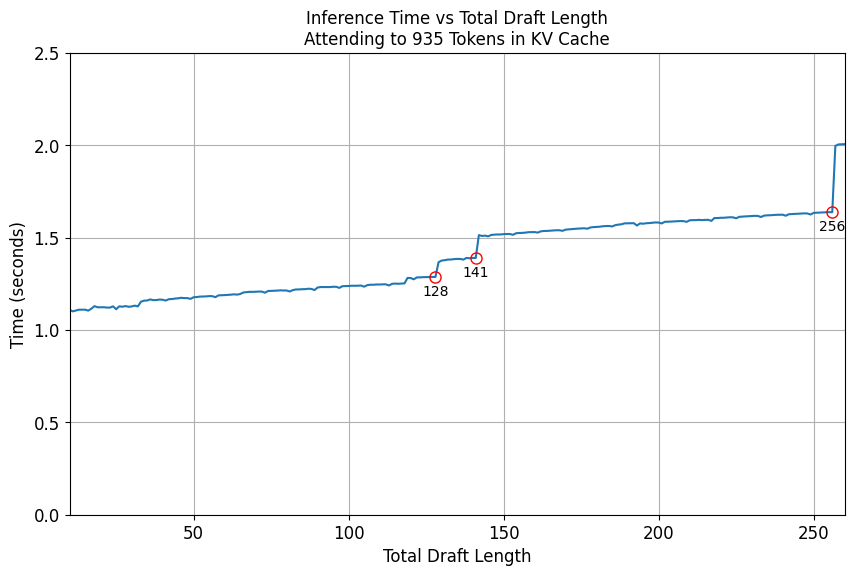

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(10, 261), test_time)
# Add red hollow circles at specific points
plt.plot(128, test_time[128-10], 'ro', markersize=8, mfc='none')  # Red hollow circle at x=128
plt.plot(141, test_time[141-10], 'ro', markersize=8, mfc='none')  # Red hollow circle at x=141
plt.plot(256, test_time[256-10], 'ro', markersize=8, mfc='none')  # Red hollow circle at x=256
# Add text labels under the circles
plt.text(128, test_time[128-10]-0.1, "128", ha='center', fontsize=10)
plt.text(141, test_time[141-10]-0.1, "141", ha='center', fontsize=10)
plt.text(256, test_time[256-10]-0.1, "256", ha='center', fontsize=10)
plt.xlabel('Total Draft Length', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('Inference Time vs Total Draft Length\nAttending to 935 Tokens in KV Cache')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(10, 260)
plt.ylim(0, 2.5)
plt.grid(True)
plt.savefig('inference_time_vs_draft_length.png', dpi=300, bbox_inches='tight')
plt.show()



In [28]:
test_time[142-10]

1.512826919555664

In [29]:
test_time[141-10]

1.3896071910858154

In [17]:
input_ids = tokenizer(input_text, return_tensors="pt").to("cuda")["input_ids"]

In [18]:
input_ids.shape

torch.Size([1, 935])

### Test Shotgun Cache Chaining

In [1]:
from model.shotgun.lru_cache import ShotgunCache, ShotgunCacheConfig
from model.shotgun.shotgun import get_chained_draft_tokens, make_chained_4d_attention_mask, make_chained_position_ids

In [2]:
shotgun_cache = ShotgunCache([
    ShotgunCacheConfig(
        prefix_capacity=2**20,
        followup_capacity=8,
        prefix_len=2,
        followup_len=2,
    )
])

In [3]:
shotgun_cache.update_cache([0, 0, 11, 11])
shotgun_cache.update_cache([0, 0, 22, 22])
shotgun_cache.update_cache([0, 0, 33, 33])
shotgun_cache.update_cache([11, 11, 111, 111])
shotgun_cache.update_cache([11, 11, 222, 222])
shotgun_cache.update_cache([111, 111, 1111, 1111])


In [4]:
prefix_ids = [0, 0]
drafts, sum_drafts_len = get_chained_draft_tokens(prefix_ids, shotgun_cache, 100)

depth 0
prefix_ids [0, 0] ->  [0, 0]
prefix_ids [0, 0] ->  [0, 0]
remain_total_drafts_len 94
depth 1
prefix_ids [0, 0] ->  [0, 0]
visiting child ((11, 11), [])
prefix_ids [0, 0] ->  [0, 0, 11, 11]
prefix_ids [0, 0, 11, 11] ->  [0, 0]
remain_total_drafts_len 90
visiting child ((22, 22), [])
prefix_ids [0, 0] ->  [0, 0, 22, 22]
prefix_ids [0, 0, 22, 22] ->  [0, 0]
remain_total_drafts_len 90
visiting child ((33, 33), [])
prefix_ids [0, 0] ->  [0, 0, 33, 33]
prefix_ids [0, 0, 33, 33] ->  [0, 0]
remain_total_drafts_len 90
prefix_ids [0, 0] ->  [0, 0]
remain_total_drafts_len 90
depth 2
prefix_ids [0, 0] ->  [0, 0]
visiting child ((11, 11), [((111, 111), []), ((222, 222), [])])
prefix_ids [0, 0] ->  [0, 0, 11, 11]
visiting child ((111, 111), [])
prefix_ids [0, 0, 11, 11] ->  [0, 0, 11, 11, 111, 111]
prefix_ids [0, 0, 11, 11, 111, 111] ->  [0, 0, 11, 11]
remain_total_drafts_len 88
visiting child ((222, 222), [])
prefix_ids [0, 0, 11, 11] ->  [0, 0, 11, 11, 222, 222]
prefix_ids [0, 0, 11, 11, 2

In [5]:
prefix_ids

[0, 0]

In [6]:
def recursive_print_prefix_tree(prefix_tree_node, depth):
    tab = "    " * depth
    print(tab, prefix_tree_node[0])
    for child in prefix_tree_node[1]:
        recursive_print_prefix_tree(child, depth + 1)


In [7]:
recursive_print_prefix_tree(drafts, 0)

 []
     (11, 11)
         (111, 111)
             (1111, 1111)
         (222, 222)
     (22, 22)
     (33, 33)


In [8]:
prefix_ids = [0, 0]
drafts, sum_drafts_len = get_chained_draft_tokens(prefix_ids, shotgun_cache, 11)

depth 0
prefix_ids [0, 0] ->  [0, 0]
prefix_ids [0, 0] ->  [0, 0]
remain_total_drafts_len 5
depth 1
prefix_ids [0, 0] ->  [0, 0]
visiting child ((11, 11), [])
prefix_ids [0, 0] ->  [0, 0, 11, 11]
prefix_ids [0, 0, 11, 11] ->  [0, 0]
remain_total_drafts_len 1
visiting child ((22, 22), [])
prefix_ids [0, 0] ->  [0, 0, 22, 22]
prefix_ids [0, 0, 22, 22] ->  [0, 0]
remain_total_drafts_len 1
visiting child ((33, 33), [])
prefix_ids [0, 0] ->  [0, 0, 33, 33]
prefix_ids [0, 0, 33, 33] ->  [0, 0]
remain_total_drafts_len 1
prefix_ids [0, 0] ->  [0, 0]
remain_total_drafts_len 1
depth 2
prefix_ids [0, 0] ->  [0, 0]
visiting child ((11, 11), [((111, 111), []), ((222, 222), [])])
prefix_ids [0, 0] ->  [0, 0, 11, 11]
visiting child ((111, 111), [])
prefix_ids [0, 0, 11, 11] ->  [0, 0, 11, 11, 111, 111]
prefix_ids [0, 0, 11, 11, 111, 111] ->  [0, 0, 11, 11]
remain_total_drafts_len 1
visiting child ((222, 222), [])
prefix_ids [0, 0, 11, 11] ->  [0, 0, 11, 11, 222, 222]
prefix_ids [0, 0, 11, 11, 222, 22

In [9]:
recursive_print_prefix_tree(drafts, 0)

 []
     (11, 11)
         (111, 111)
         (222, 222)
     (22, 22)
     (33, 33)


In [10]:
sum_drafts_len

10

In [8]:
mask = make_chained_4d_attention_mask(
    cached_prefix_len=1,
    uncached_prefix_len=2,
    drafts_root=drafts,
    sum_drafts_len=sum_drafts_len,
)


In [9]:
mask

array([[1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.]],
      dtype=float16)

In [10]:
make_chained_position_ids(
    cached_prefix_len=1,
    uncached_prefix_len=2,
    drafts_root=drafts,
    sum_drafts_len=sum_drafts_len,
)


array([1, 2, 3, 4, 5, 6, 7, 8, 5, 6, 3, 4, 3, 4])

### Examine SpecBench Questions

In [1]:
import json

# Parse the JSON file
questions = []
with open("data/spec_bench/question.jsonl", "r") as f:
    for line in f:
        questions.append(json.loads(line))

# Display the first question to see the structure
questions[0]


{'question_id': 81,
 'category': 'writing',
 'turns': ['Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.',
  'Rewrite your previous response. Start every sentence with the letter A.']}

In [2]:
s = set()
for question in questions:
    s.add(question["category"])


In [3]:
s

{'coding',
 'extraction',
 'humanities',
 'math',
 'math_reasoning',
 'qa',
 'rag',
 'reasoning',
 'roleplay',
 'stem',
 'summarization',
 'translation',
 'writing'}

In [4]:
classification = {
    "coding": "multi-turn conversation",
    "extraction": "multi-turn conversation",
    "humanities": "multi-turn conversation",
    "math": "multi-turn conversation",
    "reasoning": "multi-turn conversation",
    "roleplay": "multi-turn conversation",
    "stem": "multi-turn conversation",
    "writing": "multi-turn conversation",
    "math_reasoning": "math reasoning",
    "rag": "rag",
    "qa": "question answering",
    "translation": "translation",
    "summarization": "summarization",
}

In [5]:
count = {}

for question in questions:
    category = classification[question["category"]]
    count[category] = count.get(category, 0) + 1

count

{'multi-turn conversation': 80,
 'translation': 80,
 'summarization': 80,
 'question answering': 80,
 'math reasoning': 80,
 'rag': 80}

### Plot Radar Chart

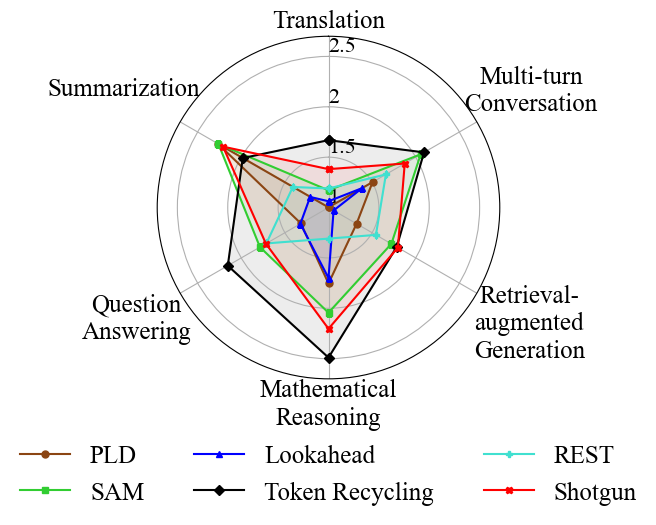

In [41]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['pdf.fonttype'] = 42

categories = [
    "Translation",
    "Multi-turn Conversation", 
    "Retrieval-augmented Generation",
    "Mathematical Reasoning",
    "Question Answering",
    "Summarization",
]
n_vars  = len(categories)
angles  = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]       # close the loop

series  = ["PLD", "SAM", "Lookahead", "Token Recycling", "REST", "Shotgun"]
markers = ["o", "s", "^", "D", "P", "X"]
colors = ["saddlebrown", "limegreen", "blue", "black", "turquoise", "red"]

speedup = {}
speedup["PLD"] = [1.0019423949260422, 1.504804263127846, 1.3217129821971485, 1.753625168310784, 1.3162166703287939, 2.270247376509052]
speedup["REST"] = [1.1893369106430685, 1.6578516484572587, 1.5433047317562405, 1.3082504800319112, 1.7122602418693675, 1.408377479104808]
speedup["Lookahead"] = [1.0623674333455722, 1.3856650442350353, 1.05840390756457, 1.699403000805275, 1.3223337294270223, 1.2105832704822186]
speedup["Token Recycling"] = [1.668698583422594, 2.0948710591039226, 1.781848390205051, 2.4894054327270476, 2.1542436123023196, 1.9826221722716753]
speedup["SAM"] = [1.1710267031397237, 2.0566317420010174, 1.7206779815642856, 2.043825459304564, 1.7857920021333402, 2.2609229118140424]
speedup["Shotgun"] = [1.3812449892907617, 1.8736913985406338, 1.7951701988706679, 2.2031872347672325, 1.7174958639066351, 2.2087243975604243]


def radar(ax, data, title, series, markers, colors):
    ax.set_theta_offset(np.pi / 2)      # start at top
    ax.set_theta_direction(-1)          # clockwise
    
    # Customize position for each category label
    label_angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False)
    label_positions = {
        "Translation": (label_angles[0], "Translation", 2.85),  # Closer to circle
        "Multi-turn Conversation": (label_angles[1], "Multi-turn\nConversation", 3.32),  # Further out
        "Retrieval-augmented Generation": (label_angles[2], "Retrieval-\naugmented\nGeneration", 3.30),  # Medium distance
        "Mathematical Reasoning": (label_angles[3], "Mathematical\nReasoning", 2.95),  # Slightly out
        "Question Answering": (label_angles[4], "Question\nAnswering", 3.20),  # Close to circle
        "Summarization": (label_angles[5], "Summarization", 3.35)  # Closer to circle
    }
    
    ax.set_xticks(label_angles)
    
    # Set each label position individually using different radial distances
    for angle, label, radius in label_positions.values():
        ax.text(angle, radius, label,
                ha='center', va='center',
                fontfamily='Times New Roman',
                fontsize=18,
                transform=ax.transData)
    ax.set_xticklabels([])  # Hide default labels
    
    ax.set_ylim(1, 2.70)
    ax.set_yticks([1, 1.5, 2, 2.5])
    ax.set_yticklabels([1, 1.5, 2, 2.5], fontfamily='Times New Roman', fontsize=16)
    ax.set_rlabel_position(0)

    for idx, label in enumerate(series):
        vals = data[label]
        vals = vals + vals[:1]          # close polygon
        ax.plot(
            angles,
            vals,
            linewidth=1.5,
            marker=markers[idx % len(markers)],
            markersize=5,
            label=label,
            color=colors[idx % len(colors)]
        )
        ax.fill(angles, vals, alpha=0.07, color=colors[idx % len(colors)])

    # ax.set_title(title, y=1.1, fontsize=14)
    ax.legend(
        loc='center',
        bbox_to_anchor=(0.5, -0.28),
        frameon=False,
        ncol=3,
        prop={'family': 'Times New Roman', 'size': 18}
    )


fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
radar(ax, speedup, "Wall Clock Speedup on SpecBench", series, markers, colors)
plt.tight_layout()
plt.savefig("radar.pdf", bbox_inches='tight')
plt.show()

### Calculate Answer Statistics

In [5]:
import json

def print_accepted_lengths(path):
    model_answers = []
    with open(path, "r") as f:
        for line in f:
            model_answers.append(json.loads(line))

    classification = {
        "coding": "Multi-turn Conversation",
        "extraction": "Multi-turn Conversation",
        "humanities": "Multi-turn Conversation",
        "math": "Multi-turn Conversation",
        "reasoning": "Multi-turn Conversation",
        "roleplay": "Multi-turn Conversation",
        "stem": "Multi-turn Conversation",
        "writing": "Multi-turn Conversation",
        "math_reasoning": "Mathematical Reasoning",
        "rag": "Retrieval-augmented Generation",
        "qa": "Question Answering",
        "translation": "Translation",
        "summarization": "Summarization",
    }

    accepted_lengths = {
        "Multi-turn Conversation": [],
        "Retrieval-augmented Generation": [],
        "Mathematical Reasoning": [],
        "Question Answering": [],
        "Summarization": [],
        "Translation": [],
    }

    for answer in model_answers:
        category = classification[answer["category"]]
        accepted_lengths[category].extend(answer["choices"][0]["accept_lengths"])

    for category, al in accepted_lengths.items():
        if len(al) > 0:
            print(category, sum(al) / len(al))
        else:
            print(category, 0)
    
    mean_accepted_len = sum((sum(al) for al in accepted_lengths.values())) / sum((len(al) for al in accepted_lengths.values()))
    print(f"Mean accepted length {mean_accepted_len}")


In [12]:
import json

def print_token_generation_speed(path):
    model_answers = []
    with open(path, "r") as f:
        for line in f:
            model_answers.append(json.loads(line))

    classification = {
        "coding": "Multi-turn Conversation",
        "extraction": "Multi-turn Conversation",
        "humanities": "Multi-turn Conversation",
        "math": "Multi-turn Conversation",
        "reasoning": "Multi-turn Conversation",
        "roleplay": "Multi-turn Conversation",
        "stem": "Multi-turn Conversation",
        "writing": "Multi-turn Conversation",
        "math_reasoning": "Mathematical Reasoning",
        "rag": "Retrieval-augmented Generation",
        "qa": "Question Answering",
        "translation": "Translation",
        "summarization": "Summarization",
    }

    new_tokens = {
        "Multi-turn Conversation": [],
        "Retrieval-augmented Generation": [],
        "Mathematical Reasoning": [],
        "Question Answering": [],
        "Summarization": [],
        "Translation": [],
    }

    wall_clock_times = {
        "Multi-turn Conversation": [],
        "Retrieval-augmented Generation": [],
        "Mathematical Reasoning": [],
        "Question Answering": [],
        "Summarization": [],
        "Translation": [],
    }

    for answer in model_answers:
        category = classification[answer["category"]]
        new_tokens[category].extend(answer["choices"][0]["new_tokens"])
        wall_clock_times[category].extend(answer["choices"][0]["wall_time"])

    category_sumed_tokens = []
    category_sumed_times = []

    for category in new_tokens.keys():
        category_new_tokens = sum(new_tokens[category])
        category_wall_time = sum(wall_clock_times[category])
        category_sumed_tokens.append(category_new_tokens)
        category_sumed_times.append(category_wall_time)
        print(category, category_new_tokens / category_wall_time, "tok/s")

    print("Average", sum(category_sumed_tokens) / sum(category_sumed_times), "tok/s")

In [9]:
print_accepted_lengths("plot_data/shotgun_partial_answer/vicuna-7b-v1.3-shotgun-only-frozen-float16.jsonl")

Multi-turn Conversation 1.5582916789179653
Retrieval-augmented Generation 1.6548025353486104
Mathematical Reasoning 1.633828323071351
Question Answering 1.608894430590191
Summarization 1.6096734094247938
Translation 1.6028416779431665
Mean accepted length 1.591672792187336


In [13]:
print_token_generation_speed("plot_data/shotgun_partial_answer/vicuna-7b-v1.3-shotgun-only-frozen-float16.jsonl")

Multi-turn Conversation 67.57907766031757 tok/s
Retrieval-augmented Generation 64.05763220910086 tok/s
Mathematical Reasoning 73.61579894579623 tok/s
Question Answering 72.53275058929074 tok/s
Summarization 63.04598511881875 tok/s
Translation 73.8565753071539 tok/s
Average 68.10847307552963 tok/s


### Heat Map

In [117]:
import os
import json

def mean_accepted_length(path):
    model_answers = []
    with open(path, "r") as f:
        for line in f:
            model_answers.append(json.loads(line))

    classification = {
        "coding": "Multi-turn Conversation",
        "extraction": "Multi-turn Conversation",
        "humanities": "Multi-turn Conversation",
        "math": "Multi-turn Conversation",
        "reasoning": "Multi-turn Conversation",
        "roleplay": "Multi-turn Conversation",
        "stem": "Multi-turn Conversation",
        "writing": "Multi-turn Conversation",
        "math_reasoning": "Mathematical Reasoning",
        "rag": "Retrieval-augmented Generation",
        "qa": "Question Answering",
        "translation": "Translation",
        "summarization": "Summarization",
    }

    accepted_lengths = {
        "Multi-turn Conversation": [],
        "Retrieval-augmented Generation": [],
        "Mathematical Reasoning": [],
        "Question Answering": [],
        "Summarization": [],
        "Translation": [],
    }

    for answer in model_answers:
        category = classification[answer["category"]]
        accepted_lengths[category].extend(answer["choices"][0]["accept_lengths"])
    
    mean_accepted_len = sum((sum(al) for al in accepted_lengths.values())) / sum((len(al) for al in accepted_lengths.values()))
    return mean_accepted_len

def grid_mean_accepted_length(dir_path, cr):
    data = []
    for p in range(1, 6):
        row = []
        for f in range(1, 6):
            file_name = f"vicuna-7b-v1.3-shotgun-float16-p{p}-f{f}-cr{cr}.jsonl"
            path = os.path.join(dir_path, file_name)
            row.append(mean_accepted_length(path))
        data.append(row)
    return data

grid = grid_mean_accepted_length("data/shotgun_128_cr16_answer", 16)

In [122]:
print(repr(grid))

[[2.1410781620967367, 2.4862284146538274, 2.499261407156144, 2.46454406109662, 2.4255262527609975], [2.1221688083572157, 2.329520724733033, 2.303362220132659, 2.254531964881909, 2.1913887087865906], [1.7670754424091897, 1.8342383764715209, 1.8319431695733728, 1.8141155227571588, 1.791954291954292], [1.5408399088778104, 1.545404217483937, 1.5242799592130116, 1.529504048582996, 1.5273062112841118], [1.3917440216389008, 1.4054481626011361, 1.4045631693620155, 1.392298010805501, 1.3982088281356913]]


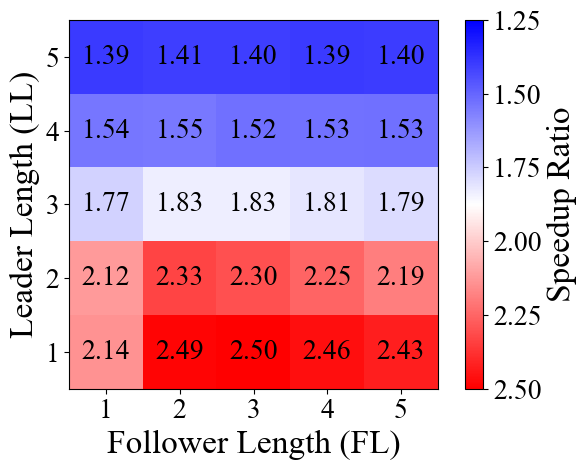

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Generate example data for a 5x5 heatmap

grid = [
    [2.1410781620967367, 2.4862284146538274, 2.499261407156144, 2.46454406109662, 2.4255262527609975],    # leader length = 1
    [2.1221688083572157, 2.329520724733033, 2.303362220132659, 2.254531964881909, 2.1913887087865906],    # leader length = 2
    [1.7670754424091897, 1.8342383764715209, 1.8319431695733728, 1.8141155227571588, 1.791954291954292],  # leader length = 3
    [1.5408399088778104, 1.545404217483937, 1.5242799592130116, 1.529504048582996, 1.5273062112841118],   # leader length = 4
    [1.3917440216389008, 1.4054481626011361, 1.4045631693620155, 1.392298010805501, 1.3982088281356913]   # leader length = 5
]

data = grid[::-1]  # Reverse the data rows to match the reversed y-axis
num_row = len(data)
num_col = len(data[0])

plt.rcParams['pdf.fonttype'] = 42

fig, ax = plt.subplots()
im = ax.imshow(data, cmap='bwr', vmin=1.25, vmax=2.50)

# Add colorbar with manual ticks
cbar = plt.colorbar(im)
cbar.set_ticks([1.25, 1.50, 1.75, 2.00, 2.25, 2.50])
cbar.ax.invert_yaxis()  # Only invert the colorbar axis
cbar.ax.set_ylabel('Speedup Ratio', fontfamily='Times New Roman', size=24)
cbar.ax.tick_params(labelsize=20)
for label in cbar.ax.get_yticklabels():
    label.set_family('Times New Roman')

# Annotate each cell with its numeric value
for i in range(num_row):
    for j in range(num_col):
        ax.text(j, i, f"{data[i][j]:.2f}", ha='center', va='center', fontfamily='Times New Roman', size=20)

# Set tick marks to show grid indices
ax.set_xticks(np.arange(num_col))
ax.set_yticks(np.arange(num_row))
ax.set_xticklabels(np.arange(1, num_col+1), fontfamily='Times New Roman', size=20)
ax.set_yticklabels(np.arange(5, 0, -1), fontfamily='Times New Roman', size=20)
ax.set_xlabel('Follower Length (FL)', fontfamily='Times New Roman', size=24)
ax.set_ylabel('Leader Length (LL)', fontfamily='Times New Roman', size=24)

plt.tight_layout()
plt.savefig("heatmap.pdf", bbox_inches='tight')
plt.show()

### Wall Clock Time

In [1]:
import json

def get_wall_clock_time(path):
    model_answers = []
    with open(path, "r") as f:
        for line in f:
            model_answers.append(json.loads(line))

    classification = {
        "coding": "Multi-turn Conversation",
        "extraction": "Multi-turn Conversation",
        "humanities": "Multi-turn Conversation",
        "math": "Multi-turn Conversation",
        "reasoning": "Multi-turn Conversation",
        "roleplay": "Multi-turn Conversation",
        "stem": "Multi-turn Conversation",
        "writing": "Multi-turn Conversation",
        "math_reasoning": "Mathematical Reasoning",
        "rag": "Retrieval-augmented Generation",
        "qa": "Question Answering",
        "translation": "Translation",
        "summarization": "Summarization",
    }

    wall_clock_time = {
        "Multi-turn Conversation": {},
        "Retrieval-augmented Generation": {},
        "Mathematical Reasoning": {},
        "Question Answering": {},
        "Summarization": {},
        "Translation": {},
    }

    for answer in model_answers:
        category = classification[answer["category"]]
        ques_id = answer["question_id"]
        wall_clock_time[category][ques_id] = sum(answer["choices"][0]["wall_time"])
    
    return wall_clock_time

def print_wall_clock_speedup(path, baseline_path, exclude_ques_id=None):
    baseline_path
    wall_clock_time = get_wall_clock_time(path)
    baseline_wall_clock_time = get_wall_clock_time(baseline_path)

    speedups = []
    for category in wall_clock_time.keys():
        total_time = 0
        base_total_time = 0

        for ques_id in wall_clock_time[category].keys():
            if exclude_ques_id is not None and ques_id in exclude_ques_id:
                continue

            total_time += wall_clock_time[category][ques_id]
            base_total_time += baseline_wall_clock_time[category][ques_id]

        speedup = base_total_time / total_time
        print(category, speedup)
        speedups.append(speedup)

    print("Average", sum(speedups) / len(speedups))

In [2]:
print_wall_clock_speedup(
    path="data/spec_bench/model_answer/vicuna-7b-v1.3-shotgun-float16.jsonl",
    baseline_path="data/spec_bench/model_answer/vicuna-7b-v1.3-baseline-float16.jsonl"
)

Multi-turn Conversation 1.9588319752844199
Retrieval-augmented Generation 1.7896547874420017
Mathematical Reasoning 2.207679848758376
Question Answering 1.6555849439711108
Summarization 2.158926482395113
Translation 1.2521601168454166
Average 1.8371396924494061


### Bar Plot

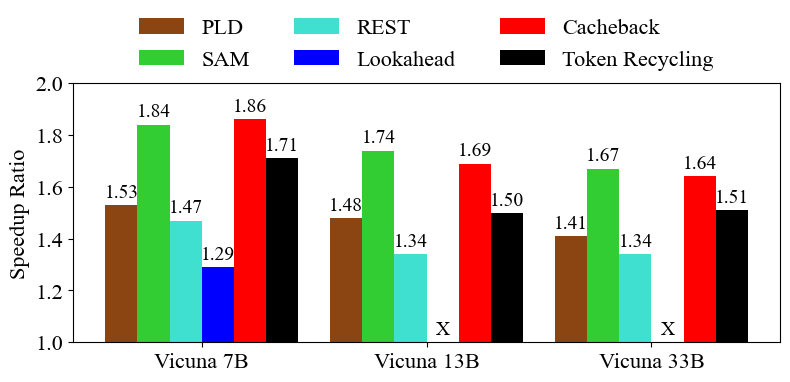

In [16]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['pdf.fonttype'] = 42

# Data for the bar plot
models = ['Vicuna 7B', 'Vicuna 13B', 'Vicuna 33B']
data = {
    'PLD': [1.53, 1.48, 1.41],
    'SAM': [1.84, 1.74, 1.67],
    'REST': [1.47, 1.34, 1.34],
    'Lookahead': [1.29, 0, 0],
    'Cacheback': [1.86, 1.69, 1.64],
    'Token Recycling': [1.71, 1.50, 1.51],
}

# Define colors for each method
colors = {
    'PLD': 'saddlebrown',  # Blue
    'SAM': 'limegreen',  # Orange  
    'Lookahead': 'blue',  # Red
    'Token Recycling': 'black',  # Brown
    'REST': 'turquoise',  # Green
    'Cacheback': 'red',  # Purple
}

n_methods = len(data)
x = np.arange(len(models)) * 0.7  # Reduced spacing between groups by multiplying by 0.5
bar_width = 0.10  # Width of each individual bar

fig, ax = plt.subplots(figsize=(8, 4))

# Plot each method's bars
for idx, (method, values) in enumerate(data.items()):
    offsets = x + (idx - n_methods / 2) * bar_width + bar_width / 2
    bars = ax.bar(offsets, values, width=bar_width, label=method, color=colors[method])
    
    # Annotate bar values
    for bar in bars:
        height = bar.get_height()
        if height == 0:
            text_height = 1
            text = 'X'
        else:
            text_height = height
            text = f"{height:.2f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            text_height+0.015,
            text,
            ha='center',
            va='bottom',
            fontsize=14,
            fontfamily="Times New Roman"
        )

# Customize axes and title
ax.set_ylabel('Speedup Ratio', fontsize=16, fontfamily="Times New Roman")
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=16, fontfamily="Times New Roman")
ax.set_ylim(1.0, 2.0)
ax.tick_params(axis='y', labelsize=16, labelfontfamily="Times New Roman")  # Set y-axis tick label font size

# Move legend above plot
plt.legend(
    bbox_to_anchor=(0.5, 1.15),
    loc='center',
    frameon=False,
    ncol=3,
    prop={'family': 'Times New Roman', 'size': 16}
)
plt.tight_layout()
plt.savefig("bars.pdf", bbox_inches='tight')
plt.show()